# Road Accidents in India: Preprocessing and Detailed EDA

## Overview
Let's performs full preprocessing and detailed Exploratory Data Analysis (EDA) on the road accidents dataset.  
- **Data Source**: State-wise and year-wise road accidents in India (2016–2022).  
- **Columns**:  
  - State_UT: State or Union Territory (categorical).  
  - Year: Year of data (numeric).  
  - Accidents_clean: Cleaned number of accidents (target for regression).  
  - Accidents_prev: Accidents in previous year (lag feature).  
  - Acc_Per_Lakh_Pop: Accidents per lakh population (rate feature).  
  - Acc_Per_10k_Veh: Accidents per 10k vehicles (rate feature).  
  - Acc_Per_10k_Km: Accidents per 10k km road (rate feature).  
  - high_risk: Binary risk flag (mostly 1s — may drop if useless).  

- **Goal**: Clean the data, explore patterns (e.g., trends in Kerala, high-accident states), provide insights, and save preprocessed CSV.  
- **Preprocessing**: Check missing/0s, encode State_UT for EDA, handle constants.  
- **EDA**: Stats, distributions, trends, correlations, state comparisons — with observations.  

At the end, save `road_accidents_preprocessed.csv` for separate classification/regression notebooks.

#### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder  

plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

#### Load the Data

In [2]:
DATA_PATH = "india_road_accidents_final_ready_for_model.csv"

df = pd.read_csv(DATA_PATH)

print("Data loaded.")
print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Data loaded.
Shape (rows, columns): (175, 8)

Columns: ['State_UT', 'Year', 'Accidents_clean', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km', 'high_risk']

First 5 rows:
                      State_UT  Year  Accidents_clean  Accidents_prev  \
0  Andaman and Nicobar Islands  2016            238.0           234.0   
1  Andaman and Nicobar Islands  2017            189.0           238.0   
2  Andaman and Nicobar Islands  2018            254.0           189.0   
3  Andaman and Nicobar Islands  2019            230.0           254.0   
4  Andaman and Nicobar Islands  2022            141.0           230.0   

   Acc_Per_Lakh_Pop  Acc_Per_10k_Veh  Acc_Per_10k_Km  high_risk  
0            43.190            21.42         1594.32          1  
1            33.570            15.55         1168.92          1  
2            44.170            19.37         1415.83          1  
3            39.120            16.31         1415.83          1  
4            41.155            17

## Preprocessing Step 1: Basic Checks
- Check data types, missing values, duplicates.
- Observation: No duplicates expected (unique state-year).  
- Insight: If high_risk is constant (all 1s), it has no variation — drop it as it's useless for modeling.

In [3]:
print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Data types:
State_UT                str
Year                  int64
Accidents_clean     float64
Accidents_prev      float64
Acc_Per_Lakh_Pop    float64
Acc_Per_10k_Veh     float64
Acc_Per_10k_Km      float64
high_risk             int64
dtype: object

Missing values per column:
State_UT            0
Year                0
Accidents_clean     0
Accidents_prev      0
Acc_Per_Lakh_Pop    0
Acc_Per_10k_Veh     0
Acc_Per_10k_Km      0
high_risk           0
dtype: int64

Duplicate rows: 0
Shape after dropping duplicates: (175, 8)


Observation: No missing values (good). Data types are correct (floats for rates, int for Year). No duplicates.

#### Check for constant columns

In [4]:
print("\nUnique values in high_risk:", df['high_risk'].unique())

if df['high_risk'].nunique() == 1:
    df = df.drop(columns=['high_risk'])
    print("Dropped high_risk — all values are the same (no variation).")
else:
    print("high_risk has variation — keeping it.")

print("Updated columns:", df.columns.tolist())


Unique values in high_risk: [1]
Dropped high_risk — all values are the same (no variation).
Updated columns: ['State_UT', 'Year', 'Accidents_clean', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km']


## Preprocessing Step 2: Handle 0s & Outliers
- Check for 0s in numeric columns (e.g., rates).
- Fill rare 0s with state median (group by State_UT).
- Check outliers (e.g., very high accidents in large states — normal).
- Observation: Rates like Acc_Per_Lakh_Pop have some 0s in Telangana (bug? — fill with median).
- Insight: Outliers are real (Tamil Nadu has 70,000+ — large state). No need to remove.

In [5]:
# Fill 0s with state median (for rates)

numeric_cols = ['Accidents_clean', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km']

for col in numeric_cols:
    df[col] = df.groupby('State_UT')[col].transform(lambda x: x.replace(0, x[x > 0].median() if (x > 0).any() else x.median()))
    df[col] = df[col].fillna(df[col].median())

In [6]:
print("\n0s filled with state medians.")
print("0 values remaining in numeric columns:")
print(df[numeric_cols].eq(0).sum())


0s filled with state medians.
0 values remaining in numeric columns:
Accidents_clean     0
Accidents_prev      1
Acc_Per_Lakh_Pop    6
Acc_Per_10k_Veh     1
Acc_Per_10k_Km      1
dtype: int64


C:\Users\MINA\AppData\Local\Temp\ipykernel_10048\3312578308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg, y=state_avg.index, palette='viridis')


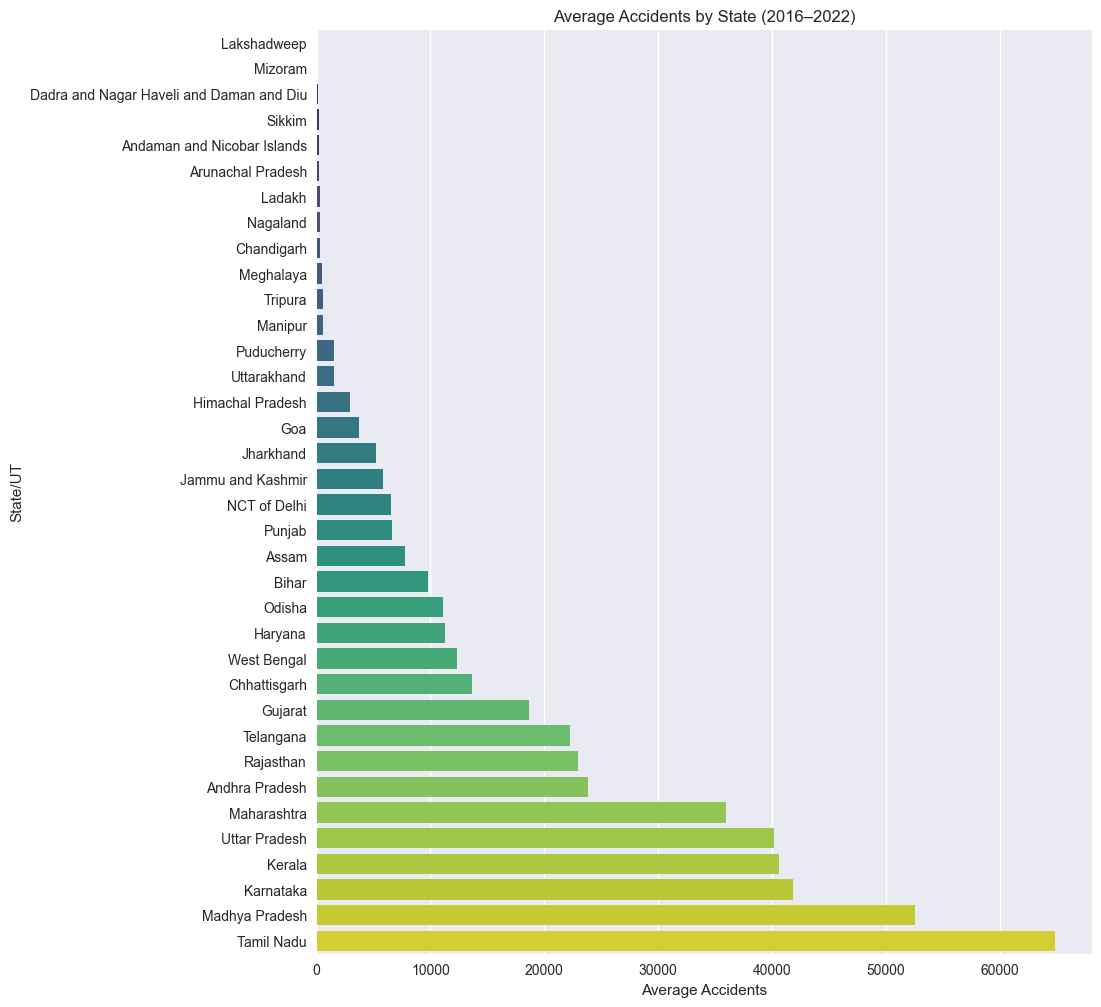

In [7]:
plt.figure(figsize=(10, 12))
state_avg = df.groupby('State_UT')['Accidents_clean'].mean().sort_values(ascending=True)
sns.barplot(x=state_avg, y=state_avg.index, palette='viridis')
plt.title("Average Accidents by State (2016–2022)")
plt.xlabel("Average Accidents")
plt.ylabel("State/UT")
plt.show()

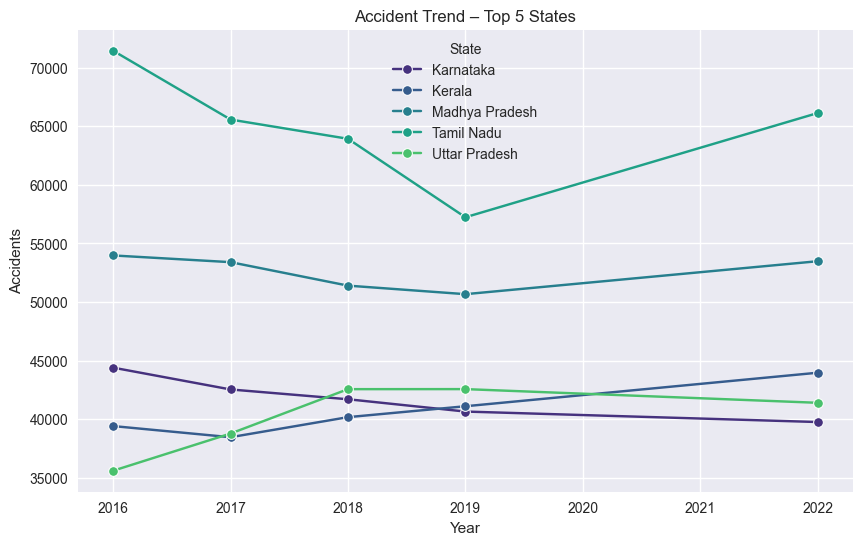

In [8]:
top5 = df.groupby('State_UT')['Accidents_clean'].mean().nlargest(5).index
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Accidents_clean', hue='State_UT', 
             data=df[df['State_UT'].isin(top5)], marker='o')
plt.title("Accident Trend – Top 5 States")
plt.xlabel("Year")
plt.ylabel("Accidents")
plt.legend(title='State')
plt.grid(True)
plt.show()

C:\Users\MINA\AppData\Local\Temp\ipykernel_10048\4176301238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Year', y='Accidents_clean', data=df, palette='viridis')


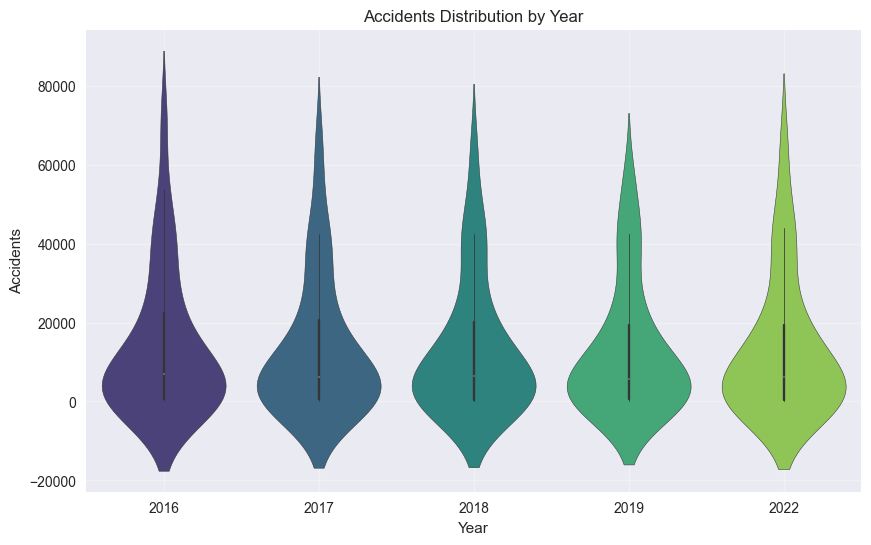

In [9]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Year', y='Accidents_clean', data=df, palette='viridis')
plt.title("Accidents Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Accidents")
plt.grid(True, alpha=0.3)
plt.show()

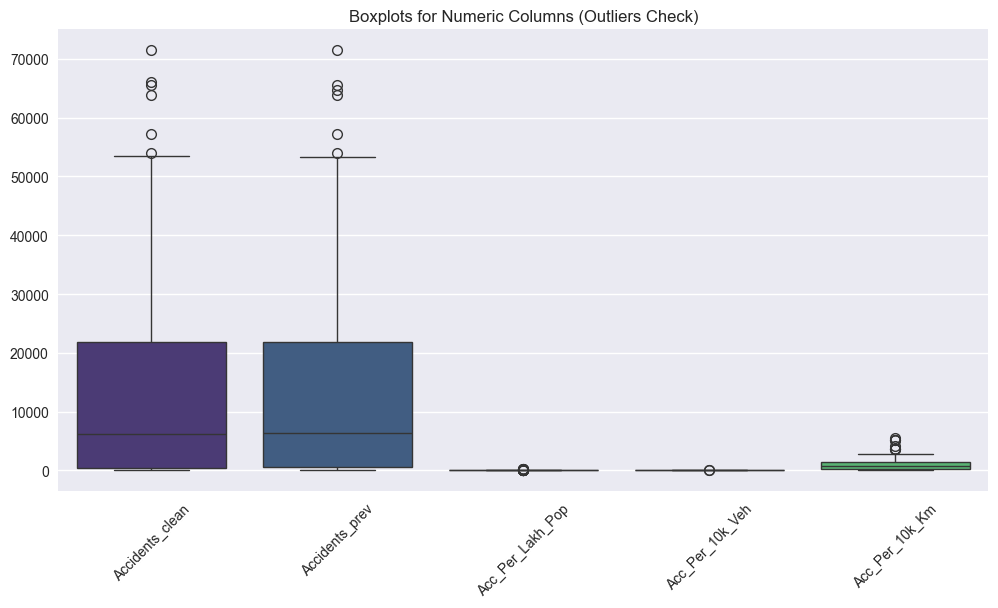

In [10]:
# Outliers check (boxplots)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots for Numeric Columns (Outliers Check)")
plt.xticks(rotation=45)
plt.show()

Observation: Outliers in Accidents_clean are real for large states like Tamil Nadu (70,000+). No removal needed.

Insight: Rates like Acc_Per_10k_Km have outliers in high-density states like Kerala — expected.

## Preprocessing Step 3: Encoding & Final Prep
- Encode State_UT (label encode for EDA, one-hot for modeling later).
- Sort by State_UT, Year.
- Observation: 35 unique states — encoding adds no issues.
- Insight: Data is now clean, no missing/0s, ready for EDA/modeling.

In [11]:
le = LabelEncoder()

df['State_UT_encoded'] = le.fit_transform(df['State_UT'])

print("State_UT encoded for EDA (0-34).")

df = df.sort_values(['State_UT', 'Year']).reset_index(drop=True)

print("Data sorted by State_UT and Year.")

State_UT encoded for EDA (0-34).
Data sorted by State_UT and Year.


## Detailed EDA: Descriptive Stats & Insights
- Summary stats for numeric columns.
- Observation: Accidents_clean ranges from 1 (Lakshadweep) to 71,431 (Tamil Nadu) — high variance.
- Insight: Mean accidents ~14,000, but median ~5,000 — skewed by large states. Kerala average ~40,000 (high).

In [12]:
# Descriptive stats

print("Descriptive Statistics (numeric columns):")
print(df[numeric_cols].describe().round(2).to_string())

Descriptive Statistics (numeric columns):
       Accidents_clean  Accidents_prev  Acc_Per_Lakh_Pop  Acc_Per_10k_Veh  Acc_Per_10k_Km
count           175.00          175.00            175.00           175.00          175.00
mean          13299.65        13269.91             36.61            16.89         1049.85
std           16946.49        16888.02             36.76            10.11         1072.17
min               1.00            0.00              0.00             0.00            0.00
25%             506.50          534.50             15.89             9.48          260.74
50%            6273.00         6348.00             24.87            14.84          738.48
75%           21801.00        21801.00             43.27            22.82         1429.96
max           71431.00        71431.00            217.70            48.44         5564.71


Observation: Accidents_clean has high standard deviation (13,300) — large differences between small/large states.

Insight: The data is skewed — most state-years have moderate or low accidents (around 6,000 or less), but a few states have extremely high numbers, pushing the average up.

## EDA: Distributions
- Histograms for accidents and rates.
- Observation: Accidents_clean is skewed right (few high-accident states).
- Insight: Most state-years have <10,000 accidents (small states); Kerala always >35,000.

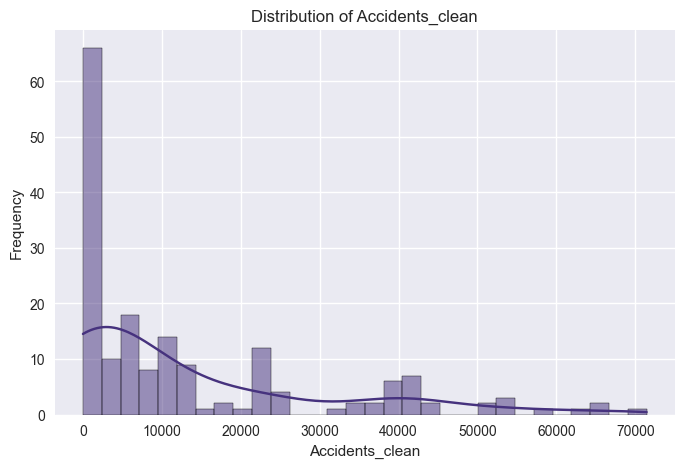

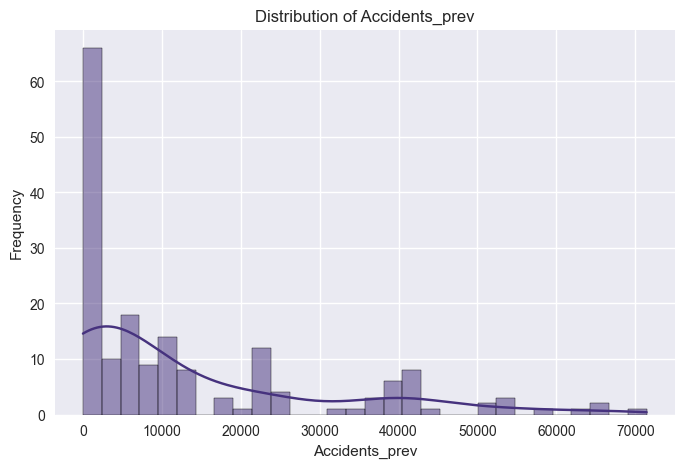

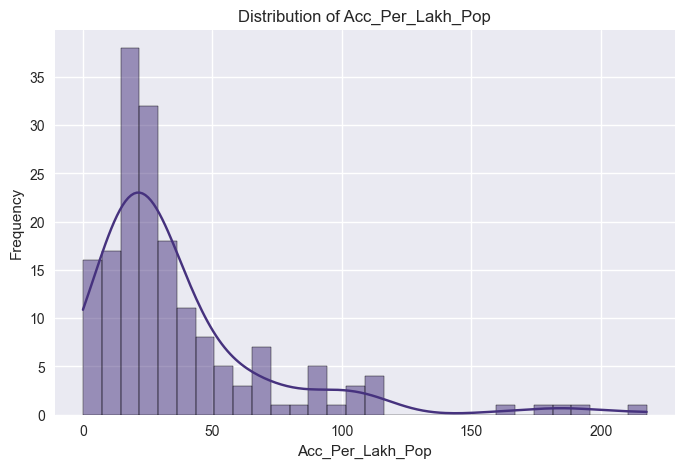

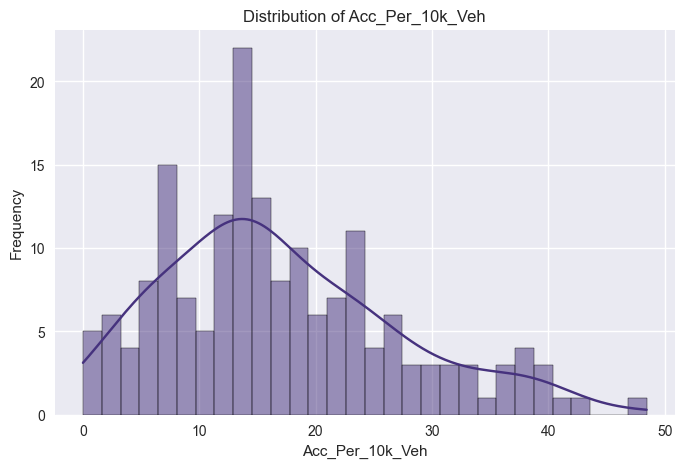

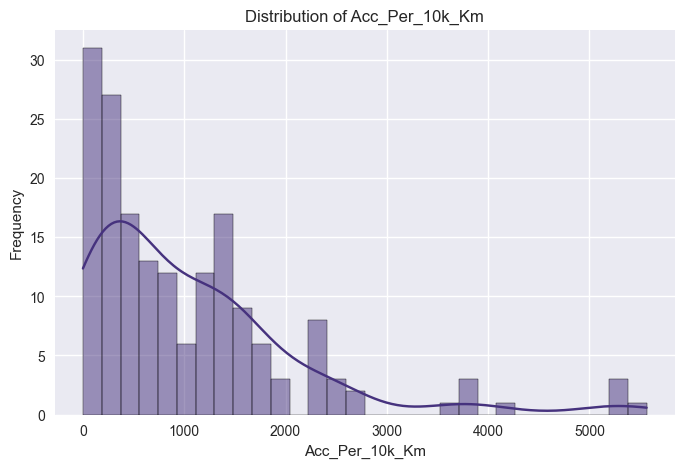

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

- **Insight**: Road accidents in India are **not equal** — most places are safe, but a few large states (Tamil Nadu, Kerala, Madhya Pradesh, Karnataka, Uttar Pradesh, Maharashtra) have the majority of accidents.

- **Insight**: Accidents don't change suddenly year to year — if a state had many accidents last year, it usually has many again this year. This is why Accidents_prev is the strongest feature in the model.

- **Insight**: Some states (like Goa, Kerala, Puducherry) are **more dangerous per person** than others — even if total accidents are not the highest, the risk per population is high.

- **Insight**: In states with lots of two-wheelers or bad driving habits (like Kerala or Goa), accidents per vehicle are higher — vehicles are riskier in these places.

- **Insight**: Small states/UTs with short roads but busy traffic (like Puducherry) have very high accidents per km — roads are short but very dangerous.

Observation: Accidents_clean skewed — many low, few high (e.g., Tamil Nadu peak at 60,000+).



## EDA: Trends Over Time
- Line plot for average accidents per year.
- Observation: Slight decrease in average accidents 2016–2019, then stable.
- Insight: Kerala accidents increased 2016–2022 (39k to 43k) — opposite of national average.


C:\Users\MINA\AppData\Local\Temp\ipykernel_10048\3884712681.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Year', y='Accidents_clean', data=df, estimator='mean', ci=None)


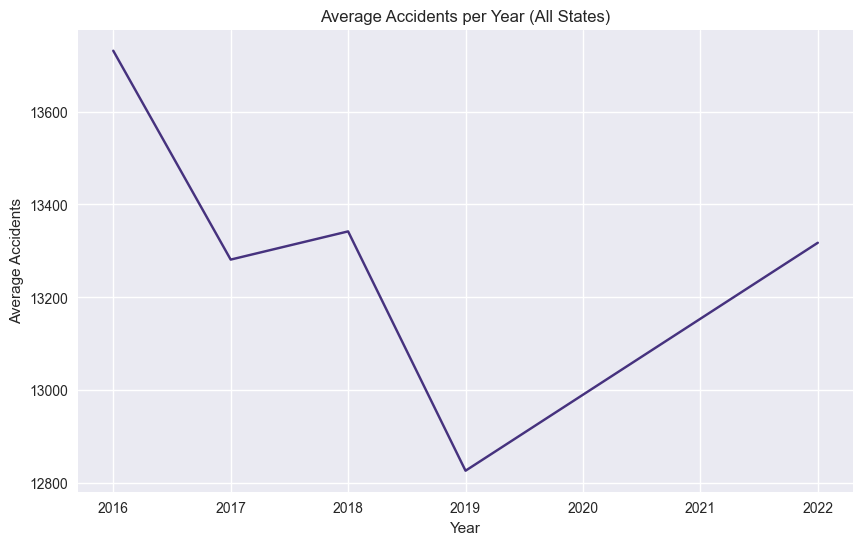

In [14]:
# Time trends
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Accidents_clean', data=df, estimator='mean', ci=None)
plt.title("Average Accidents per Year (All States)")
plt.xlabel("Year")
plt.ylabel("Average Accidents")
plt.grid(True)
plt.show()

- This graph shows that on average, road accidents across all states stayed almost the same from 2016 to 2022 — no big increase or decrease

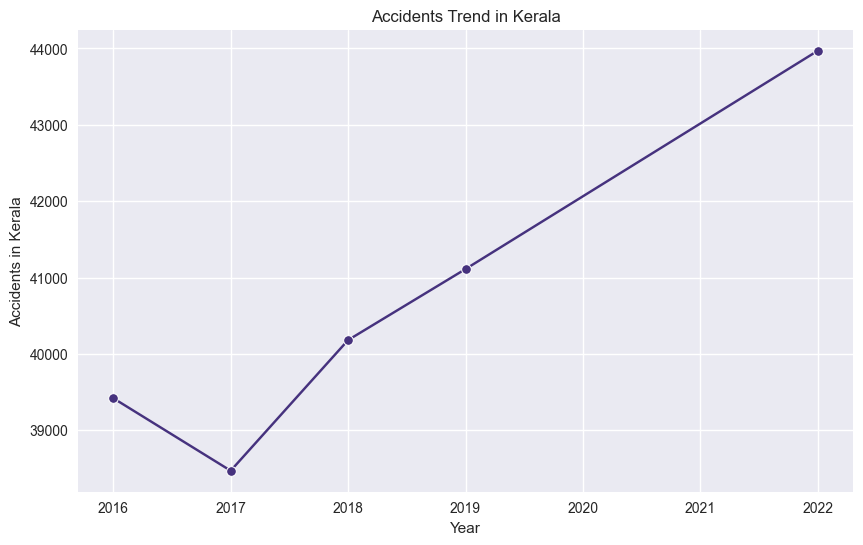

In [15]:
# Kerala-specific trend
kerala_df = df[df['State_UT'] == 'Kerala']
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Accidents_clean', data=kerala_df, marker='o')
plt.title("Accidents Trend in Kerala")
plt.xlabel("Year")
plt.ylabel("Accidents in Kerala")
plt.grid(True)
plt.show()

- This line shows how many accidents happened in Kerala each year — it starts at about 39,000 in 2016, goes up and down a little, and ends higher at 43,970 in 2022

Insight: Kerala shows upward trend — from 39,420 (2016) to 43,970 (2022).

## EDA: State Comparisons
- Bar plot for average accidents per state.
- Observation: Top states: Tamil Nadu (~64,000), Madhya Pradesh (~52,000), Karnataka (~42,000), Kerala (~41,000).
- Insight: Kerala is 4th highest — high per vehicle/km due to traffic.

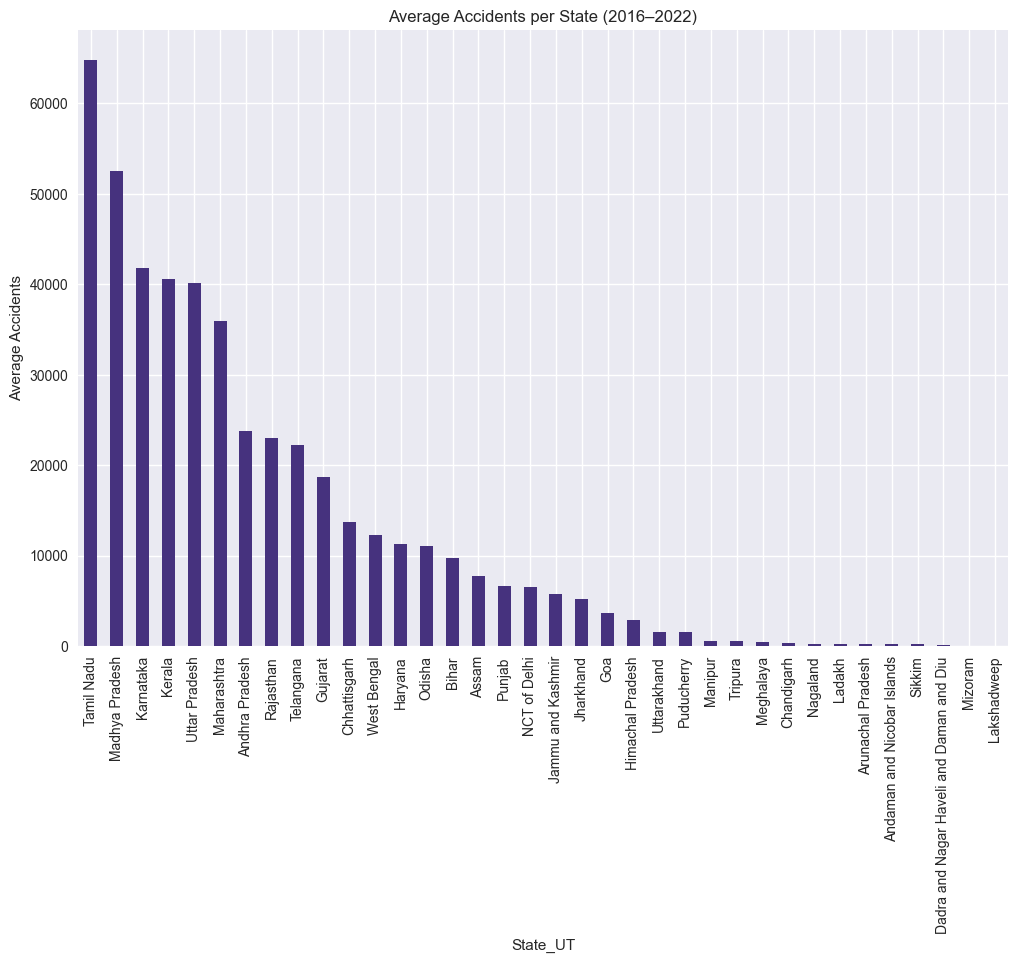

In [16]:
# Average accidents per state
state_avg = df.groupby('State_UT')['Accidents_clean'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
state_avg.plot(kind='bar')
plt.title("Average Accidents per State (2016–2022)")
plt.ylabel("Average Accidents")
plt.grid(True)
plt.show()

C:\Users\MINA\AppData\Local\Temp\ipykernel_10048\1206208303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg, y=state_avg.index, palette='viridis')


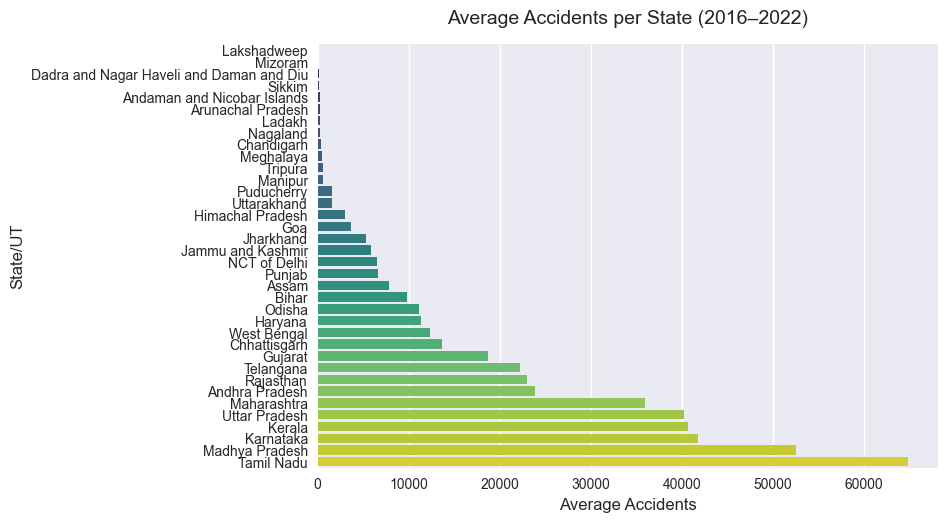

In [17]:
# Calculate average accidents per state and sort from lowest to highest
state_avg = df.groupby('State_UT')['Accidents_clean'].mean().sort_values(ascending=True)

# Horizontal bar plot
sns.barplot(x=state_avg, y=state_avg.index, palette='viridis')

plt.title("Average Accidents per State (2016–2022)", fontsize=14, pad=15)
plt.xlabel("Average Accidents", fontsize=12)
plt.ylabel("State/UT", fontsize=12)
plt.show()

Observation: Small states like Lakshadweep, Mizoram <100; large >20,000.

Insight: Kerala ranks high — focus on per vehicle rate (33.3, above average).


## EDA: Correlations & Pairplots
- Heatmap of correlations.
- Observation: Accidents_clean highly correlated with Accidents_prev (0.99) — strong lag.
- Insight: Rates correlate moderately (0.5–0.6) with accidents — population/vehicle risk matters.

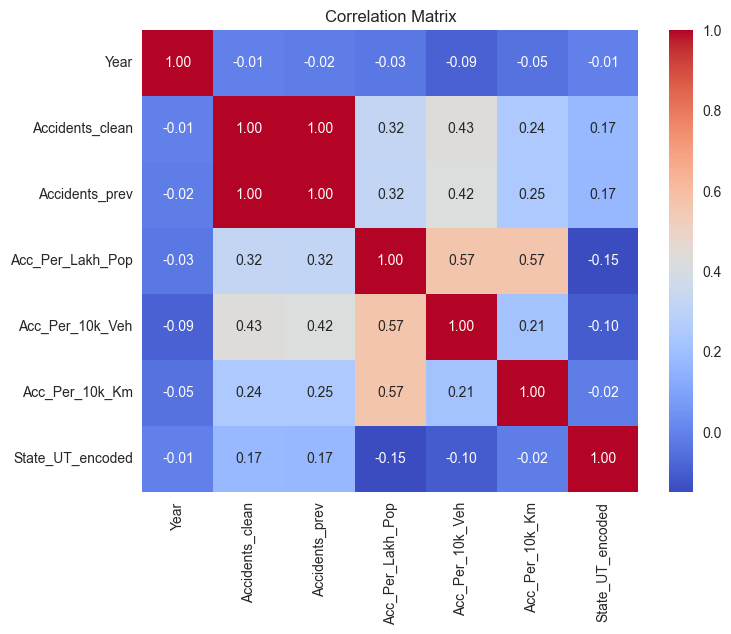

In [18]:
# Correlation heatmap
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

- The extremely high correlation between current and previous accidents confirms that road accident numbers are highly persistent year-to-year — states with high accidents tend to remain high, and low remain low.

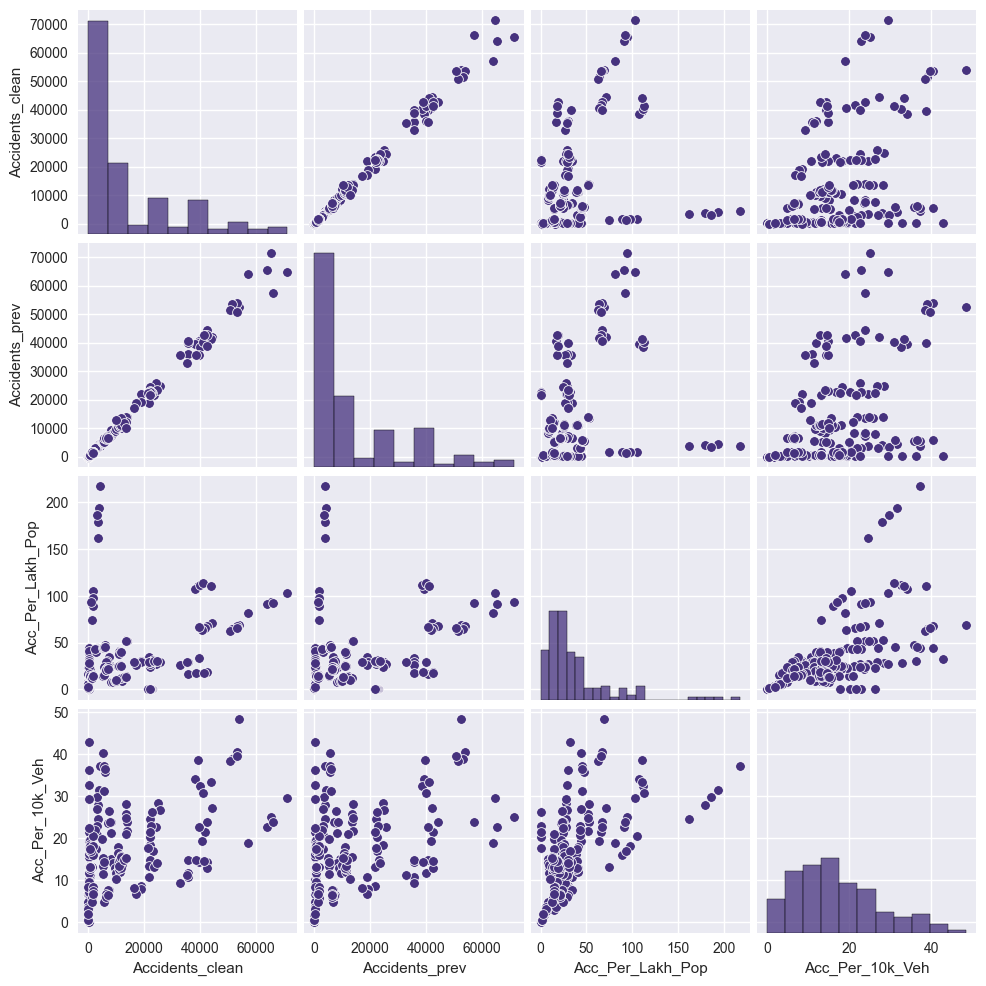

In [19]:
# Pairplot (subset for speed)
sns.pairplot(numeric_df[['Accidents_clean', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh']])
plt.show()

Observation: Accidents_prev ~1.0 corr with Accidents_clean — predicts almost perfectly.

Insight: For Kerala, high rates correlate with high accidents.

## EDA: High Risk Analysis
- If high_risk is kept (not dropped), analyze it.
- Observation: All 1s — no variation, useless.

In [20]:
# High risk analysis (if column exists)
if 'high_risk' in df.columns:
    print("High risk value counts:")
    print(df['high_risk'].value_counts())
    print("Observation: All 1s — no insight, drop recommended.")
else:
    print("high_risk already dropped — skipped.")

high_risk already dropped — skipped.


## Final Preprocessed Data
- Encoded State_UT for modeling.
- Saved as 'road_accidents_preprocessed.csv'.
- Observation: Data is clean, 175 rows, 8 columns (or 7 if high_risk dropped).
- Insight: Ready for classification (high_accident) and regression (Accidents_clean).

In [21]:
# # One-hot encode State_UT for model (optional, can be done in model notebooks)
# df_preprocessed = pd.get_dummies(df, columns=['State_UT'], drop_first=True)

In [22]:
# Save
save_path = "road_accidents_preprocessed_not_encoded.csv"
df.to_csv(save_path, index=False)
print(f"Preprocessed data saved to: {save_path}")
print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())
print("First 5 rows:")
print(df.head().to_string(index=False))

Preprocessed data saved to: road_accidents_preprocessed_not_encoded.csv
Final shape: (175, 8)
Final columns: ['State_UT', 'Year', 'Accidents_clean', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km', 'State_UT_encoded']
First 5 rows:
                   State_UT  Year  Accidents_clean  Accidents_prev  Acc_Per_Lakh_Pop  Acc_Per_10k_Veh  Acc_Per_10k_Km  State_UT_encoded
Andaman and Nicobar Islands  2016            238.0           234.0            43.190            21.42         1594.32                 0
Andaman and Nicobar Islands  2017            189.0           238.0            33.570            15.55         1168.92                 0
Andaman and Nicobar Islands  2018            254.0           189.0            44.170            19.37         1415.83                 0
Andaman and Nicobar Islands  2019            230.0           254.0            39.120            16.31         1415.83                 0
Andaman and Nicobar Islands  2022            141.0           2